This notebook shows a typical use-case of the `lightmatter` framework to infer time-dependent Drude parameters of a thin metallic flim.

In [ ]:
from lightmatter.fdtd import run_simulation
from lightmatter.fdtd import MaterialParamsTD, PulseParams, FDTDParams
from lightmatter.io import load_simulation_run, make_fdtd_gif, plot_fdtd_frame, save_simulation_run
import numpy as np
import matplotlib.pyplot as plt
from lightmatter.units import C0, C0_SI, UNIT_F, UNIT_L, UNIT_T, UNIT_E

In [8]:
# Grid + time
L = 60 * 1e4 # A
dz= 5.0 # A
Nz = int(L/dz)
dt = 0.99 * dz / C0

# Source
src_pos = 5.0 * 1e4
src_i = int(np.round(src_pos/dz))

# ----------------metal film, up to right boundary---------------------#
# metal_i0_pos = 50.0 * 1e4
# metal_i1_pos = L
# metal_i0 = int(np.round( metal_i0_pos/ dz))
# metal_i1 = Nz
# thickness = L - metal_i0_pos

#------------------ very thin metal film, but at the same position----------------#
thickness = 5.0 # 10 A
metal_i0_pos = 50.0 * 1e4
metal_cells = int(np.round(thickness / dz))
metal_i0 = int(np.round( metal_i0_pos/ dz))
metal_i1 = metal_i0 + metal_cells

print(f"metal i0: {metal_i0}, i1: {metal_i1}, thickness:{thickness} A")

#probes, for thin film
probe_r_pos = 10.0 * 1e4
probe_t_pos = metal_i0_pos + 2.0e4
probe_r_i = int(np.round(probe_r_pos/dz))
probe_t_i = int(np.round(probe_t_pos/dz))

# probes for semi-infinite metal
# probe_r_pos = 10.0 * 1e4
# probe_t_pos = metal_i0_pos + 2.0e4
# probe_r_i = int(np.round(probe_r_pos/dz))
# probe_t_i = int(np.round(probe_t_pos/dz))
print(f"ref probe pos: {probe_r_i}, transmitted probe pos: {probe_t_i}")


#------------------Pulse parameters---------------#
E0_SI = 0.1 * 1e10   #  E0 in V / m (0.1 V / A)
E0 = E0_SI / UNIT_E  #  in code units
f0 = 370.0           #  THz
tau = 0.2 * 0.5      #  200 fs
t0 = 3*tau
pulsetype = "smoothed box"
pulse = PulseParams(E0=E0, f0=f0, t0=t0, tau=tau, phase=0.0, type=pulsetype)

T_estimate_reflection = (metal_i0_pos - src_pos + metal_i0_pos - probe_r_pos) / C0 + t0*2.0

T = np.round(T_estimate_reflection + 0.005, 3) #ps
Nt = int(T/dt)
num_snaps = 5000
print(f"Nt = {Nt}, number of snapshots = {Nt//num_snaps * 0}, set to zero for now")

#------------------Simulation box parameters (with film)---------------#
simulation_params_withfilm = FDTDParams(
    Nz=Nz,
    Nt=Nt,
    dz=dz,
    dt=dt,
    src_i=src_i,
    probe_t_i=probe_t_i,
    probe_r_i=probe_r_i,
    metal_i0=metal_i0,
    metal_i1=metal_i1,
    snap_every= 0,  # 0 disables snapshots
)

#------------------Simulation box parameters (without film)---------------#
simulation_params_nofilm = FDTDParams(
    Nz=Nz,
    Nt=Nt,
    dz=dz,
    dt=dt,
    src_i=src_i,
    probe_t_i=probe_t_i,
    probe_r_i=probe_r_i,
    metal_i0=metal_i0,
    metal_i1=metal_i0, # make metal thickness=0.0
    snap_every= 0,   # 0 disables snapshots
)

#------------------Material parameters (time-dependent)---------------#
def omega_D_smoothstep(t, omega0, delta, t0, deltat):
    step = 0.5 * (1.0 + np.tanh((t - t0) / deltat))
    return omega0 + delta * step

t_ax = np.linspace(0.0,T,Nt)
omega_D0 = 2 * np.pi * 2113.6
omega_D_timedep = omega_D_smoothstep(t_ax, omega_D0, 3000, 0.45, 0.02)
omega_D_const = np.ones(Nt) * omega_D0

gamma_D0 = 2.0 * np.pi * 15.92
# gamma_D_timedep = omega_D_smoothstep(t_ax, gamma_D0, 20, 0.58, 0.01)
gamma_D_const = np.ones(Nt) * gamma_D0

material = MaterialParamsTD(
    omega_D=omega_D_const, 
    gamma_D=gamma_D_const,
    omega_L=np.ones(Nt) * 2.0*np.pi*650.07, 
    gamma_L=np.ones(Nt) * 2.0*np.pi*104.86,
    del_eps=np.ones(Nt) * 1.09 * 0.0,        #lorentz off
    eps_inf=np.ones(Nt) * 5.9673,
)


metal i0: 100000, i1: 100001, thickness:5.0 A
ref probe pos: 20000, transmitted probe pos: 104000
Nt = 538415, number of snapshots = 0, set to zero for now


In [9]:
2*np.pi*15.92


100.02831009029902

## Test plots

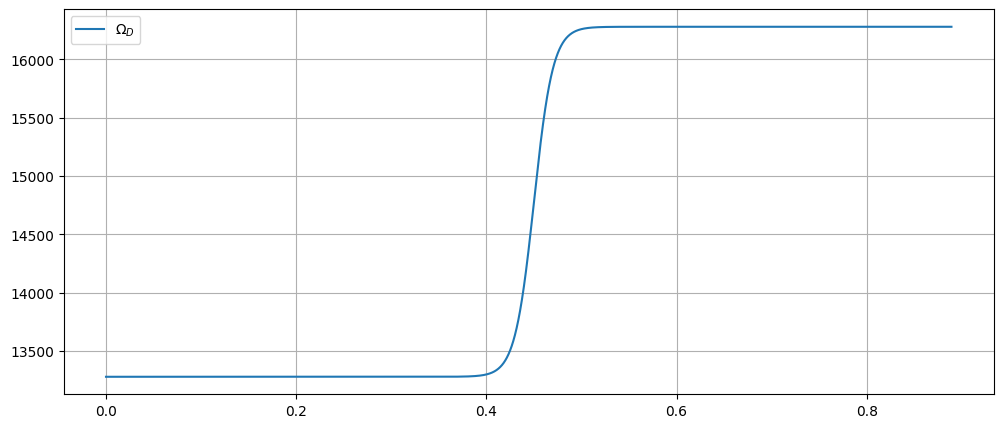

simulation time: 0.889 ps


In [3]:
fig = plt.figure(figsize=(12,5))
plt.plot(t_ax, omega_D_timedep, label=r"$\Omega_D$")
# plt.scatter(t_ax, gamma_D_timedep, label=r"$\Gamma_D$")
plt.legend()
plt.grid(True)
plt.show()
print(f"simulation time: {T} ps")

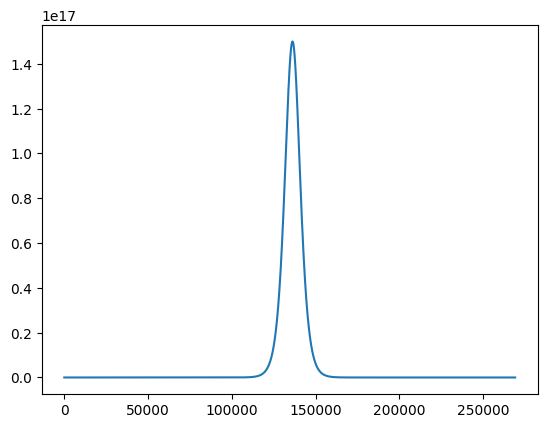

In [12]:
plt.plot((omega_D_timedep[1::] - omega_D_timedep[:-1:])/dt)

## Run FDTD simulation

In [ ]:
for freq in [1000.0,1050.0,1100.0,1200.0,1250.0]:
    pulse = PulseParams(E0=E0, f0=freq, t0=t0, tau=tau, phase=0.0, type=pulsetype)

    # filename vars
    dz_filename = 5
    root_dirname = "2026-06-11_reflection_compare_thin"
    
    #------------------constant parameters------------------#
    dirname = f"{root_dirname}/constant/f0_{freq}_step_dz_{dz_filename}"
    material = MaterialParamsTD(
        omega_D=omega_D_const, 
        gamma_D=gamma_D_const,
        omega_L=np.ones(Nt) * 2.0*np.pi*650.07, 
        gamma_L=np.ones(Nt) * 2.0*np.pi*104.86,
        del_eps=np.ones(Nt) * 1.09 * 0.0,        #lorentz off
        eps_inf=np.ones(Nt) * 5.9673,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_withfilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/with_film",
        params=simulation_params_withfilm, 
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_nofilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/nofilm",
        params=simulation_params_nofilm,
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

    #------------------time-varying parameters------------------#
    dirname = f"{root_dirname}/vary/f0_{freq}_step_dz_{dz_filename}"
    material = MaterialParamsTD(
        omega_D=omega_D_timedep, 
        gamma_D=gamma_D_const,
        omega_L=np.ones(Nt) * 2.0*np.pi*650.07, 
        gamma_L=np.ones(Nt) * 2.0*np.pi*104.86,
        del_eps=np.ones(Nt) * 1.09 * 0.0,        #lorentz off
        eps_inf=np.ones(Nt) * 5.9673,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_withfilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/with_film",
        params=simulation_params_withfilm, 
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_nofilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/nofilm",
        params=simulation_params_nofilm,
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/constant/f0_1000.0_step_dz_5/with_film
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/constant/f0_1000.0_step_dz_5/nofilm
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/vary/f0_1000.0_step_dz_5/with_film
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/vary/f0_1000.0_step_dz_5/nofilm
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/constant/f0_1050.0_step_dz_5/with_film
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/constant/f0_1050.0_step_dz_5/nofilm
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-11_reflection_compare_thin/vary/f0_1050.0_step_dz_5/with_film
Maximu

## Retrieve data

In [10]:
# high resolution runs
# dirname_const = "2026-04-28_reflection_compare_constant_hires/constant/f0_750.0_step_dz_2.5"
# dirname_vary = "2026-04-28_reflection_compare_constant_hires/vary/f0_750.0_step_dz_2.5"

# low resolution
f0_retr = 1100.0
dirname_const = f"2026-06-11_reflection_compare_thin/constant/f0_{f0_retr}_step_dz_5"
dirname_vary = f"2026-06-11_reflection_compare_thin/vary/f0_{f0_retr}_step_dz_5"

result_withfilm = load_simulation_run(f"../output/{dirname_const}/with_film",nosnaps=True)
result_nofilm = load_simulation_run(f"../output/{dirname_const}/nofilm",nosnaps=True)
result_withfilm_vary = load_simulation_run(f"../output/{dirname_vary}/with_film",nosnaps=True)
result_nofilm_vary = load_simulation_run(f"../output/{dirname_vary}/nofilm",nosnaps=True)

E_r_const = result_withfilm["E_r"] - result_nofilm["E_r"]
E_r_vary = result_withfilm_vary["E_r"] - result_nofilm_vary["E_r"]

E_t_const = result_withfilm["E_t"]
E_t_vary = result_withfilm_vary["E_t"]

Nt = result_withfilm["params"].Nt
dt = result_withfilm["params"].dt * UNIT_T
dz_retrieved = result_withfilm["params"].dz * UNIT_L
t_ax_retrieved = np.arange(Nt) * dt
f0 = result_withfilm["pulse"].f0 * UNIT_F
print(f"retrieved Pulse central frquency: {f0/UNIT_F} THz")
thickness_retrieved = (result_withfilm['params'].metal_i1 - result_withfilm['params'].metal_i0) * result_withfilm['params'].dz * UNIT_L
print(f"film thickness: {thickness_retrieved}")

simulation_params_withfilm = result_withfilm['params']

retrieved Pulse central frquency: 1100.0 THz
film thickness: 5e-10


## Waveform plots

(470.0, 680.0)

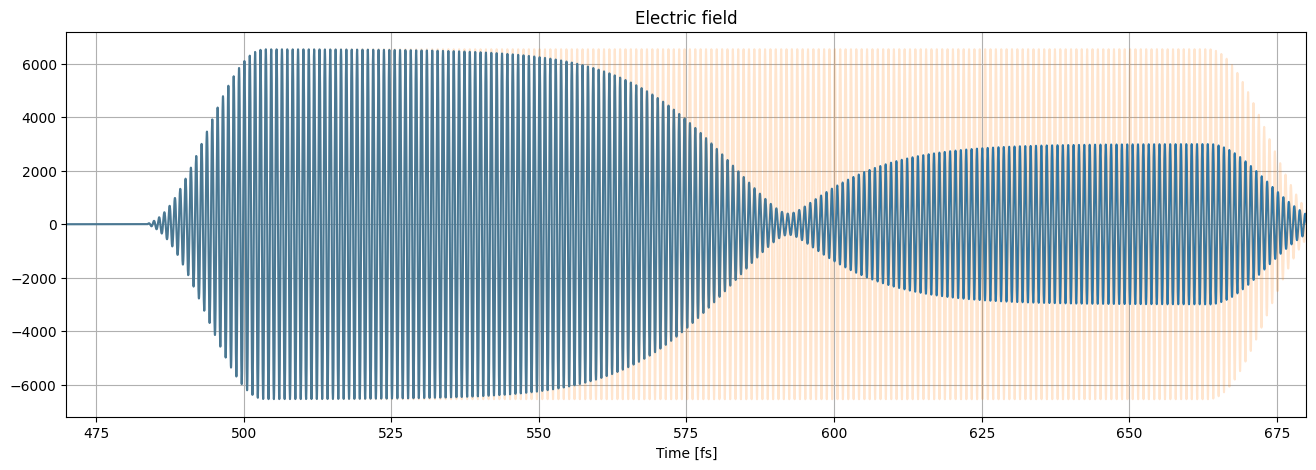

In [11]:
E_ref_vary = result_withfilm_vary["E_r"] - result_nofilm_vary["E_r"]
E_ref_const = result_withfilm["E_r"] - result_nofilm["E_r"]

# int_E_ref_vary = np.cumsum(E_ref_vary) * dt
# int_E_ref_const = np.cumsum(E_ref_const) * dt

fig = plt.figure(figsize=(16,5))
plt.plot(t_ax_retrieved*1e15, E_r_vary,label="varying")
plt.plot(t_ax_retrieved*1e15, E_r_const,label="static",alpha=0.2)
plt.title("Electric field")
plt.xlabel("Time [fs]")
plt.grid(True)
plt.xlim((4.7e2,6.8e2))
# plt.ylim((750000, 950000))

## check peaks analysis against theory, thin film

In [ ]:
# perform a forward model check with the complex transfer function from the peak analysis

from lightmatter.peak_analyzer_interpolate import epsilon_drude

num_reflections = 100
Nt_reduced = Nt//100
r_ratio = np.zeros(Nt_reduced, dtype=np.complex128)
t_ax_reduced = np.linspace(0.0,T,Nt_reduced)
delta_t_grad = (t_ax_reduced[1] - t_ax_reduced[0]) * UNIT_T
print(f"T:{T}, 1/dt_reduced:{np.round(1/(t_ax_reduced[1] - t_ax_reduced[0])*1/UNIT_T,3)}")

omega_D_timedep_reduced = omega_D_smoothstep(t_ax_reduced, omega_D0, 3000, 0.45, 0.02)
omega_arr = np.array([2*np.pi*f0_retr,]) * UNIT_F               # Ensuring this is the same as the retrieved pulse
eps_drude = np.zeros(Nt_reduced,dtype=np.complex128)
r_dyn_old = np.zeros(Nt_reduced,dtype=np.complex128)

r_dyn_modified = np.zeros(Nt_reduced, dtype=np.complex128)

for i in range(Nt_reduced):

    eps_drude[i] = epsilon_drude(
        omega=omega_arr,
        eps_inf=5.9673,
        omega_D=omega_D_timedep_reduced[i]*UNIT_F,
        gamma_D=gamma_D0*UNIT_F
    )[0]

    # r_dyn_old[i] = r_model_from_params(
    #     omega=omega_arr,
    #     omega_D=omega_D_timedep_reduced[i]*UNIT_F,
    #     gamma_D=gamma_D0*UNIT_F,
    #     eps_inf=5.9673,
    #     d_m=thickness_retrieved,
    #     N_reflections=num_reflections,
    # )

# Check the expected reflection coefficient for a time-vary refractive index.

del_eps_del_t = np.gradient(eps_drude,delta_t_grad)
# del2_eps_del_t2 = np.gradient(del_eps_del_t,delta_t_grad)

n_sqr = eps_drude - 1.0j/omega_arr[0] * del_eps_del_t
n_complex = np.sqrt(n_sqr)
n_sqr_uncorrected = eps_drude
n_complex_uncorrected = np.sqrt(eps_drude)

t_complex_vary = 1.0 + 1.0j * omega_arr[0] * thickness_retrieved / (2.0 * C0_SI) * (1.0 + n_sqr)
r_complex_vary = (0.5j*omega_arr[0]*thickness_retrieved / C0_SI)*(n_sqr - 1.0) * t_complex_vary # derived

# time-constant case
eps_drude_const = epsilon_drude(omega_arr, eps_inf=5.9673, omega_D=omega_D0*UNIT_F, gamma_D=gamma_D0*UNIT_F, )
t_complex_const = 1.0 + 1.0j * omega_arr[0] * thickness_retrieved / (2.0 * C0_SI) * (1.0 + eps_drude_const)
r_complex_const = (0.5j*omega_arr[0]*thickness_retrieved / C0_SI)*(eps_drude_const - 1.0) * t_complex_const # derived

r_ratio = r_complex_vary/r_complex_const
t_ratio = t_complex_vary/t_complex_const

# define the uncorrected reflection coefficient
t_complex_uncorrected = 1.0 + 1.0j * omega_arr[0] * thickness_retrieved / (2.0 * C0_SI) * (1.0 + n_sqr_uncorrected)
r_complex_uncorrected = (0.5j*omega_arr[0]*thickness_retrieved / C0_SI)*(n_sqr_uncorrected - 1.0) * t_complex_uncorrected

r_ratio_uncorrected = r_complex_uncorrected / r_complex_const

T:0.889, 1/dt_reduced:6055118110236220.0


In [ ]:
from lightmatter.peak_analyzer_interpolate import extract_peak_ratio_time_series_from_reflections

t_mid, ratio_complex, aux = extract_peak_ratio_time_series_from_reflections(
    E_r_const,
    E_r_vary,
    t_ax_retrieved,
    f0,
    peak_prom_frac=0.05,
    peak_tol_frac=0.45,
    clip=2,
)

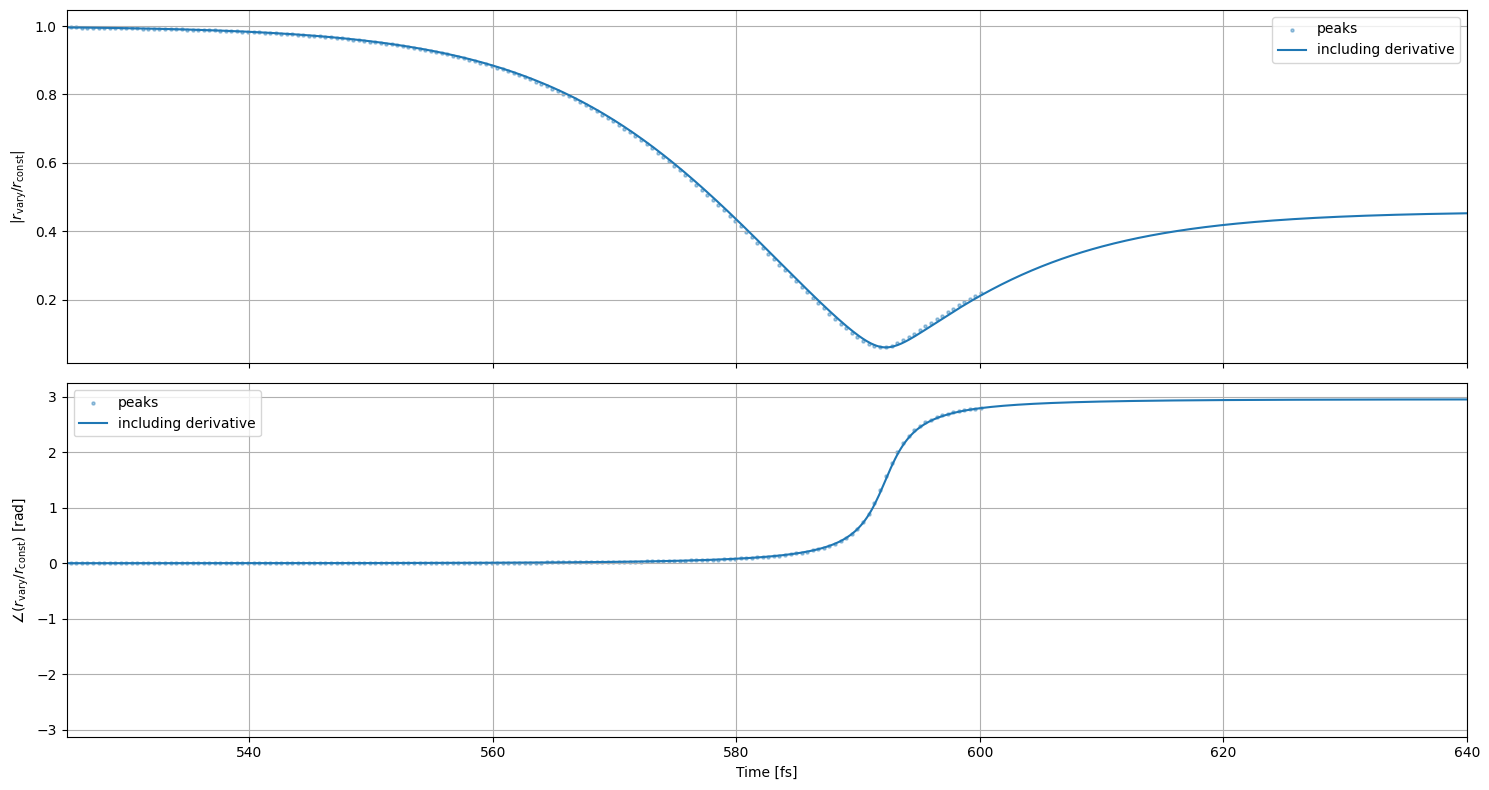

In [14]:
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

t_peaks_fs = t_mid * 1e15
t_theory_fs = (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15

fig, ax = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# -------------------------------
# Plot 1: Magnitude
# -------------------------------
ax[0].scatter(
    t_peaks_fs,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio),
    label="including derivative"
)

# ax[0].plot(
#     t_theory_fs,
#     np.abs(r_ratio_uncorrected),
#     label="not including derivative"
# )

ax[0].set_ylabel(r"$|r_{\mathrm{vary}}/r_{\mathrm{const}}|$")
ax[0].legend()
ax[0].grid(True)

# Optional magnitude limits
# ax[0].set_ylim((0.999, 1.03))


# -------------------------------
# Plot 2: Phase
# -------------------------------
ax[1].scatter(
    t_peaks_fs,
    np.angle(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio),
    label="including derivative"
)

# ax[1].plot(
#     t_theory_fs,
#     np.angle(r_ratio_uncorrected),
#     label="not including derivative"
# )

ax[1].set_xlabel("Time [fs]")
ax[1].set_ylabel(r"$\angle(r_{\mathrm{vary}}/r_{\mathrm{const}})$ [rad]")
ax[1].legend()
ax[1].grid(True)

ax[1].set_xlim((5.25e2, 6.4e2))
# ax[1].set_ylim((-0.001, 0.1))

plt.tight_layout()
plt.show()

### Check peaks analysis against theory, for a semi-infinite metal region

In [83]:
# perform a forward model check with the complex transfer function from the peak analysis

from lightmatter.infer_drude_reflection import epsilon_drude
from lightmatter.infer_drude_reflection import r_model_from_params

def ref_trans_coeffs(omega, n_complex,thickness):

    delta = (omega / C0_SI) * n_complex * thickness
    denom = (
        np.cos(delta)
        - 0.5j * (n_complex + 1.0 / n_complex) * np.sin(delta)
    )
    t_c = 1.0 / denom

    r_c = (
        0.5j * (n_complex - 1.0 / n_complex) * np.sin(delta)
    ) / denom

    return r_c,t_c

num_reflections = 100
Nt_reduced = Nt//100
r_ratio = np.zeros(Nt_reduced, dtype=np.complex128)
t_ax_reduced = np.linspace(0.0,T,Nt_reduced)
delta_t_grad = (t_ax_reduced[1] - t_ax_reduced[0]) * UNIT_T
print(f"T:{T}, 1/dt_reduced:{np.round(1/(t_ax_reduced[1] - t_ax_reduced[0])*1/UNIT_T,3)}")

omega_D_timedep_reduced = omega_D_smoothstep(t_ax_reduced, omega_D0, 3000, 0.45, 0.02)
omega_arr = np.array([2*np.pi*f0_retr,]) * UNIT_F               # Ensuring this is the same as the retrieved pulse
eps_drude = np.zeros(Nt_reduced,dtype=np.complex128)
r_dyn_old = np.zeros(Nt_reduced,dtype=np.complex128)

r_dyn_modified = np.zeros(Nt_reduced, dtype=np.complex128)

for i in range(Nt_reduced):

    eps_drude[i] = epsilon_drude(
        omega=omega_arr,
        eps_inf=5.9673,
        omega_D=omega_D_timedep_reduced[i]*UNIT_F,
        gamma_D=gamma_D0*UNIT_F
    )[0]

    # r_dyn_old[i] = r_model_from_params(
    #     omega=omega_arr,
    #     omega_D=omega_D_timedep_reduced[i]*UNIT_F,
    #     gamma_D=gamma_D0*UNIT_F,
    #     eps_inf=5.9673,
    #     d_m=thickness_retrieved,
    #     N_reflections=num_reflections,
    # )
# time-constant case
eps_drude_const = epsilon_drude(omega_arr, eps_inf=5.9673, omega_D=omega_D0*UNIT_F, gamma_D=gamma_D0*UNIT_F, )
n_complex_const = np.sqrt(eps_drude_const)


# Check the expected reflection coefficient for a time-varying refractive index.

del_eps_del_t = np.gradient(eps_drude,delta_t_grad)
n_sqr = eps_drude + 1.0j/omega_arr[0] * del_eps_del_t
n_complex = np.sqrt(n_sqr)

# modified eqn
l_eff = C0_SI/omega_arr[0] * np.sqrt(2.0/(np.abs(eps_drude_const) - np.real(eps_drude_const)))
n_sqr_modified = 1.0 - 1.0j*omega_arr[0] * l_eff / C0_SI * (eps_drude - 1.0 + 1.0j/omega_arr[0] * del_eps_del_t)
n_complex_modified = np.sqrt(n_sqr_modified)

n_sqr_uncorrected = eps_drude
n_complex_uncorrected = np.sqrt(eps_drude)

# thick case
r_complex_vary_thick,t_complex_vary_thick = ref_trans_coeffs(omega_arr[0], n_complex, thickness_retrieved)

# single interface Fresnel equation
r_complex_vary_thick_modified = (1.0 - n_complex_modified) / (1.0 + n_complex_modified)
r_complex_const_singleinterface = (1.0 - n_complex_const) / (1.0 + n_complex_const)

r_complex_constant_thick, t_complex_constant_thick = ref_trans_coeffs(omega_arr[0],n_complex_const, thickness_retrieved)

r_ratio_modified = r_complex_vary_thick_modified / r_complex_const_singleinterface
r_ratio = r_complex_vary_thick/r_complex_constant_thick
t_ratio = t_complex_vary_thick/t_complex_constant_thick

# define the uncorrected reflection coefficient
r_complex_uncorrected, t_complex_uncorrected = ref_trans_coeffs(omega_arr[0], n_complex_uncorrected, thickness_retrieved)
r_ratio_uncorrected = r_complex_uncorrected / r_complex_constant_thick

T:0.889, 1/dt_reduced:3026996625421822.0


In [84]:
r_ratio

array([1.        -0.j       , 1.        -0.j       ,
       1.        -0.j       , ..., 0.91960952-0.4543584j,
       0.91960952-0.4543584j, 0.91960952-0.4543584j], shape=(2692,))

In [ ]:
from lightmatter.peak_analyzer_interpolate import extract_peak_ratio_time_series_from_reflections

t_mid, ratio_complex, aux = extract_peak_ratio_time_series_from_reflections(
    E_r_const,
    E_r_vary,
    t_ax_retrieved,
    f0,
    peak_prom_frac=0.05,
    peak_tol_frac=0.45,
    clip=2,
)

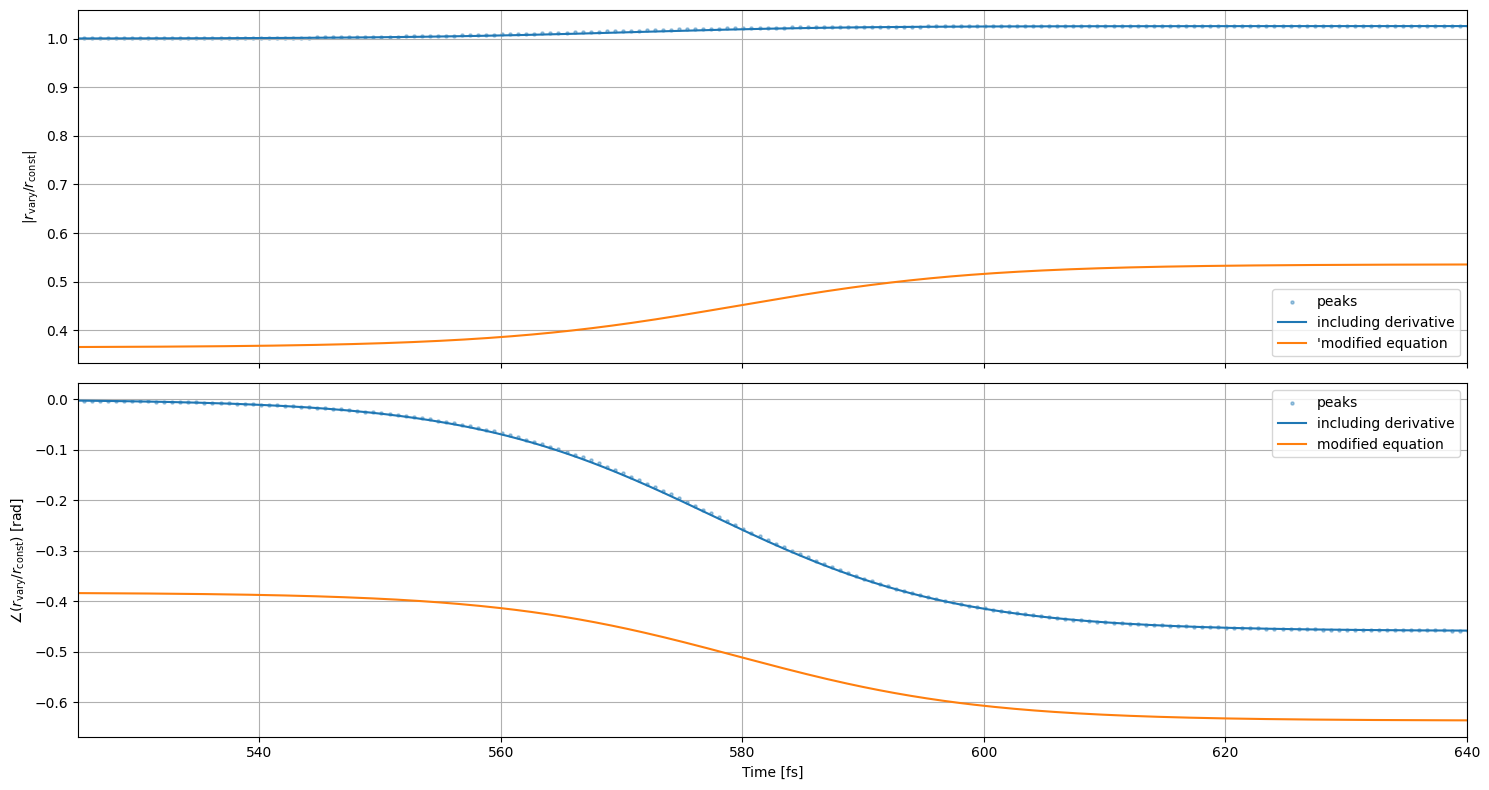

In [87]:
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

t_peaks_fs = t_mid * 1e15
t_theory_fs = (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15

fig, ax = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# -------------------------------
# Plot 1: Magnitude
# -------------------------------
ax[0].scatter(
    t_peaks_fs,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio),
    label="including derivative"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio_modified),
    label="'modified equation"
)

ax[0].set_ylabel(r"$|r_{\mathrm{vary}}/r_{\mathrm{const}}|$")
ax[0].legend()
ax[0].grid(True)

# Optional magnitude limits
# ax[0].set_ylim((0.995, 1.04))


# -------------------------------
# Plot 2: Phase
# -------------------------------
ax[1].scatter(
    t_peaks_fs,
    np.angle(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio),
    label="including derivative"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio_modified),
    label="modified equation"
)

ax[1].set_xlabel("Time [fs]")
ax[1].set_ylabel(r"$\angle(r_{\mathrm{vary}}/r_{\mathrm{const}})$ [rad]")
ax[1].legend()
ax[1].grid(True)

ax[1].set_xlim((5.25e2, 6.4e2))
# ax[1].set_ylim((-0.01, 0.005))

plt.tight_layout()
plt.show()

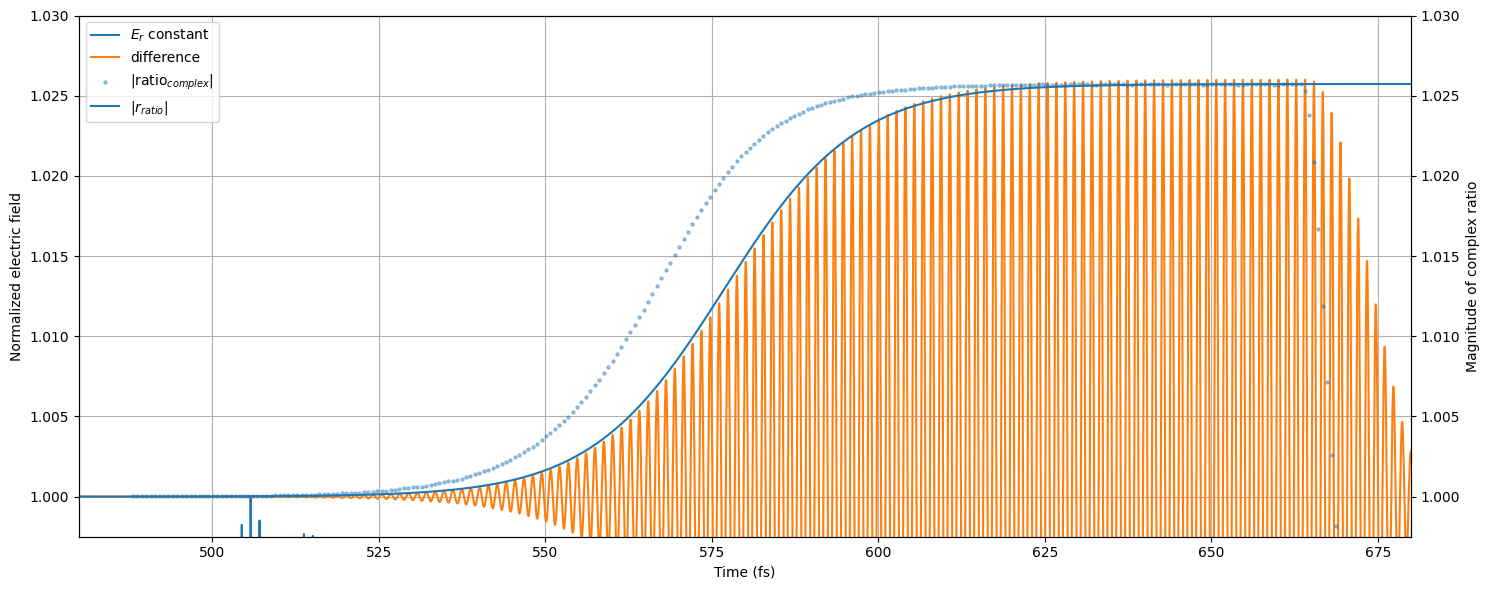

In [21]:
# -----------------------
# Time correction for ratio trace
# -----------------------
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

# -----------------------
# Figure and left axis
# -----------------------
fig, ax1 = plt.subplots(figsize=(15, 6))

# Normalize fields using the same reference
E_norm_ref = np.max(np.abs(E_r_const))

ax1.plot(
    t_ax_retrieved * 1e15,
    E_r_const / E_norm_ref,
    label=r"$E_r$ constant",
)

ax1.plot(
    t_ax_retrieved * 1e15,
    1 + 0.026*(E_r_vary - E_r_const) / np.max(E_r_vary - E_r_const),
    label="difference"
)

# ax1.plot(
#     t_ax_retrieved * 1e15,
#     E_r_vary / E_norm_ref,
#     alpha=0.5,
#     label=r"$E_r$ varying",
# )

ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Normalized electric field")
# ax1.set_xlim(5.75e2, 5.85e2)
ax1.set_xlim((4.8e2,6.8e2))
ax1.set_ylim(0.9975, 1.03)
ax1.grid(True)

# -----------------------
# Right axis for ratio
# -----------------------
ax2 = ax1.twinx()

ax2.scatter(
    t_mid * 1e15,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label=r"$|\mathrm{ratio}_{complex}|$",
)

ax2.plot(
    (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15 + 3,
    np.abs(r_ratio),
    label=r"$|r_{ratio}|$",
)

ax2.set_ylabel("Magnitude of complex ratio")

# Set independently because this axis may have different scaling
ax2.set_ylim(0.9975, 1.03)
# ax2.set_ylim(0.0, 1.03)

# -----------------------
# Combined legend
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
)

plt.tight_layout()
plt.show()

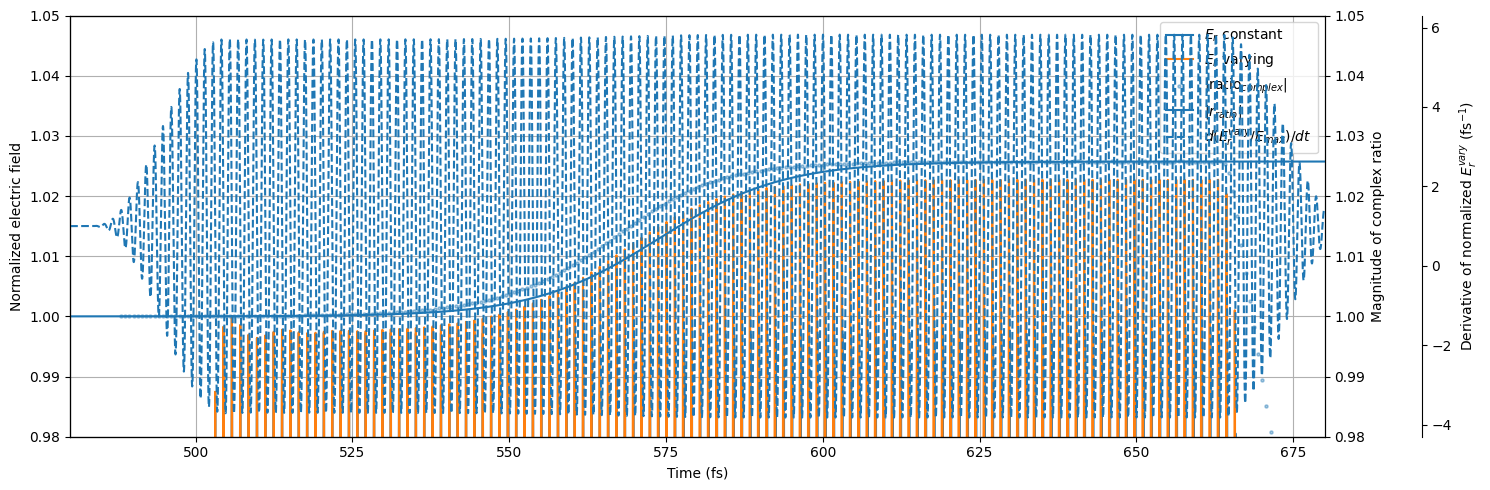

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Time correction for ratio trace
# -----------------------
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

# -----------------------
# Normalize electric fields
# -----------------------
E_norm_ref = np.max(np.abs(E_r_const))

E_const_norm = E_r_const / E_norm_ref
E_vary_norm  = E_r_vary  / E_norm_ref

# Time axis in fs
t_retrieved_fs = t_ax_retrieved * 1e15

# -----------------------
# Derivative of varying electric field trace
# Units: normalized field per fs
# -----------------------
dE_vary_dt = np.gradient(E_vary_norm, t_retrieved_fs)

# -----------------------
# Figure and left axis: electric fields
# -----------------------
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(
    t_retrieved_fs,
    E_const_norm,
    label=r"$E_r$ constant",
)

ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Normalized electric field")
ax1.set_xlim(4.8e2, 6.8e2)
ax1.set_ylim(0.98, 1.05)
ax1.grid(True)

# -----------------------
# Right axis 1: ratio_complex and r_ratio
# -----------------------
ax2 = ax1.twinx()

ax2.scatter(
    t_mid * 1e15,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label=r"$|\mathrm{ratio}_{complex}|$",
)

ax2.plot(
    (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15,
    np.abs(r_ratio),
    label=r"$|r_{ratio}|$",
)

ax2.set_ylabel("Magnitude of complex ratio")
ax2.set_ylim(0.98, 1.05)
# ax2.set_ylim(0.0, 1.03)

# -----------------------
# Right axis 2: derivative of varying electric field
# -----------------------
ax3 = ax1.twinx()

# Offset the third axis outward so it does not overlap with ax2
ax3.spines["right"].set_position(("outward", 70))

ax3.plot(
    t_retrieved_fs,
    dE_vary_dt + 1.0,
    linestyle="--",
    label=r"$d(E_r^{vary}/E_{max})/dt$",
)

ax3.set_ylabel(r"Derivative of normalized $E_r^{vary}$ $(\mathrm{fs}^{-1})$")

# Optional: set derivative axis limits manually if needed
# ax3.set_ylim(-1e-3, 1e-3)

# -----------------------
# Combined legend
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best",
)

plt.tight_layout()
plt.show()

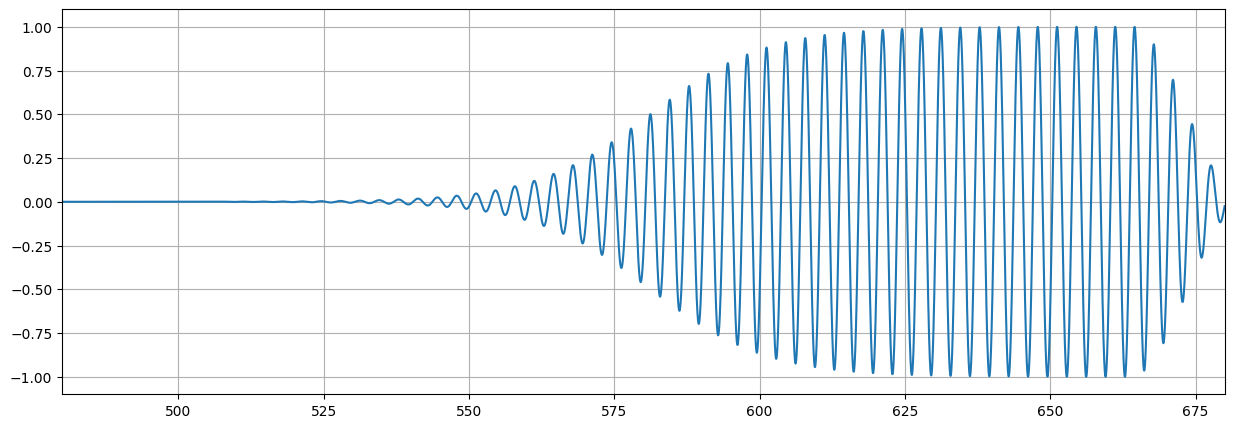

In [20]:
fig = plt.figure(figsize=(15,5))

plt.plot(t_ax_retrieved * 1e15, (E_r_vary - E_r_const) / (np.max(E_r_vary - E_r_const)))
plt.xlim((4.8e2,6.8e2))
# plt.ylim((0.,1.03))
# plt.ylim((0.999, 1.003))
plt.grid(True)


(5e-13, 7e-13)

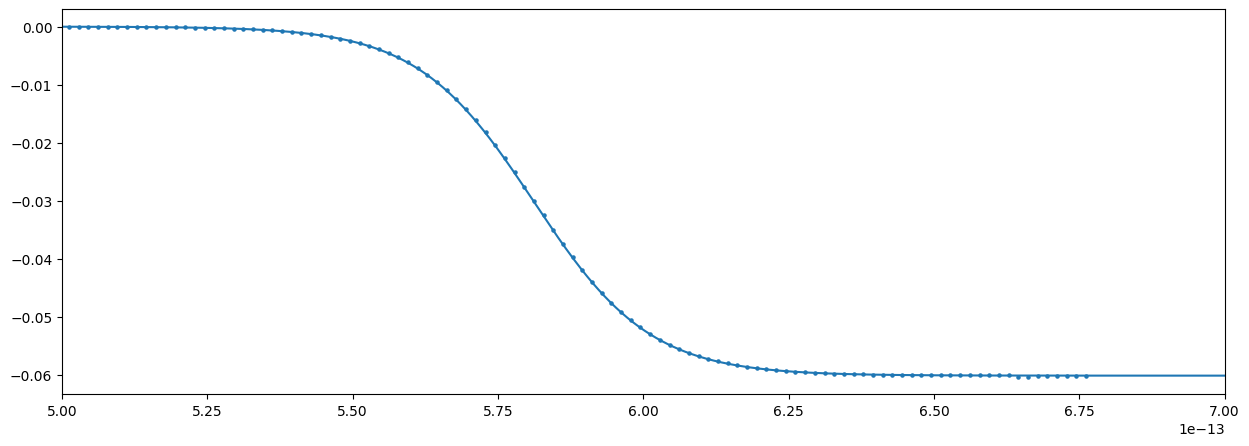

In [12]:
fig = plt.figure(figsize=(15,5))

plt.scatter(t_mid, np.angle(ratio_complex),s=5)
plt.plot(t_ax_reduced*UNIT_T + delta_t_correction, np.angle(r_ratio))
plt.xlim((5e-13,7e-13))
# plt.ylim((-0.005,0.002))

# inference; thin film

In [15]:
from lightmatter.infer_drude_derivative import infer_drude_time_series_from_multifrequency_runs

dirname_compare_const = ["2026-06-11_reflection_compare_thin_10","step_dz_10"]
result_inference_compare_const = infer_drude_time_series_from_multifrequency_runs(
    f0_arr=[650.0,750.0,850.0,950.0],
    dirname=dirname_compare_const,
    eps_inf=5.9673,
    omega_D0=omega_D0*UNIT_F,
    gamma_D0=gamma_D0*UNIT_F,
    x0=(1.32e16,1.0e14),
    bounds=((5e15, 5e13), (2.e16, 1.5e14)),
    lam_smooth=0.0,
    clip = 50
)

dirname_compare_const_5 = ["2026-06-11_reflection_compare_thin","step_dz_5"]
result_inference_compare_const_5 = infer_drude_time_series_from_multifrequency_runs(
    f0_arr=[650.0,750.0,850.0,950.0,1050.0,1100.0,1250.0],
    dirname=dirname_compare_const_5,
    eps_inf=5.9673,
    omega_D0=omega_D0*UNIT_F,
    gamma_D0=gamma_D0*UNIT_F,
    x0=(1.32e16,1.0e14),
    bounds=((5e15, 5e13), (2.e16, 1.5e14)),
    lam_smooth=0.0,
    clip = 50
)

dirname_compare_const_20 = ["2026-06-11_reflection_compare_thin_20","step_dz_20"]
result_inference_compare_const_20 = infer_drude_time_series_from_multifrequency_runs(
    f0_arr=[650.0,750.0,850.0,950.0],
    dirname=dirname_compare_const_20,
    eps_inf=5.9673,
    omega_D0=omega_D0*UNIT_F,
    gamma_D0=gamma_D0*UNIT_F,
    x0=(1.32e16,1.0e14),
    bounds=((5e15, 5e13), (2.e16, 1.5e14)),
    lam_smooth=0.0,
    clip = 50
)

In [16]:
omega_D_timedep

array([13280.14046525, 13280.14046525, 13280.14046525, ...,
       16280.14046525, 16280.14046525, 16280.14046525], shape=(538415,))

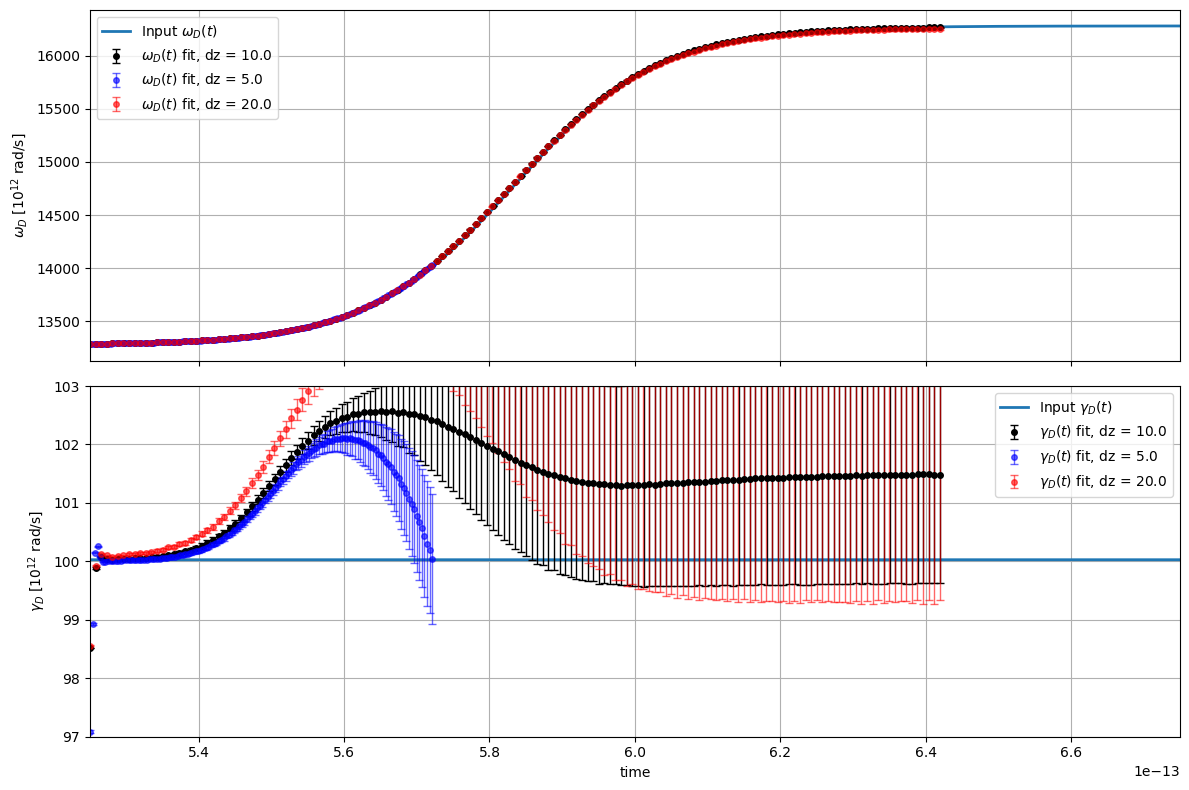

In [17]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Time correction
# ------------------------------------------------------------
delta_t_correction = (
    (result_withfilm_vary["params"].metal_i0
     - result_withfilm_vary["params"].probe_r_i)
    * dz_retrieved / C0_SI
)

# ------------------------------------------------------------
# Optional scaling for nicer axes
# ------------------------------------------------------------
omega_scale = 1e-12   # plot omega_D in units of 10^12 rad/s
gamma_scale = 1e-12   # plot gamma_D in units of 10^12 rad/s

# ------------------------------------------------------------
# Define all cases here
# Add/remove cases from this list as needed
# ------------------------------------------------------------
cases = [
    {
        "result": result_inference_compare_const,
        "label": "dz = 10.0",
        "color": "black",
        "alpha": 1.0,
    },
    {
        "result": result_inference_compare_const_5,
        "label": "dz = 5.0",
        "color": "blue",
        "alpha": 0.6,
    },
    {
        "result": result_inference_compare_const_20,  # replace with your third result dictionary
        "label": "dz = 20.0",
        "color": "red",
        "alpha": 0.6,
    },
]

# ------------------------------------------------------------
# Common x-axis limits
# ------------------------------------------------------------
xlim_common = (5.25e-13, 6.75e-13)

# ------------------------------------------------------------
# Create shared-x plots
# ------------------------------------------------------------
fig, (ax_omega, ax_gamma) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

# ------------------------------------------------------------
# Plot input/reference curves
# ------------------------------------------------------------
ax_omega.plot(
    t_ax * UNIT_T + delta_t_correction,
    omega_D_timedep,
    label=r"Input $\omega_D(t)$",
    linewidth=2
)

ax_gamma.plot(
    t_ax * UNIT_T + delta_t_correction,
    gamma_D_const,
    label=r"Input $\gamma_D(t)$",
    linewidth=2
)

# ------------------------------------------------------------
# Plot all fitted cases with error bars
# ------------------------------------------------------------
for case in cases:
    result = case["result"]

    t_fit = result["time"]

    omegaD_t = result["omegaD_t"]
    gammaD_t = result["gammaD_t"]

    omegaD_err = result["omegaD_err"]
    gammaD_err = result["gammaD_err"]

    label = case["label"]
    color = case["color"]
    alpha = case["alpha"]

    ax_omega.errorbar(
        t_fit,
        omegaD_t * omega_scale,
        yerr=omegaD_err * omega_scale,
        fmt="o",
        color=color,
        alpha=alpha,
        capsize=3,
        elinewidth=1,
        markersize=4,
        label=rf"$\omega_D(t)$ fit, {label}"
    )

    ax_gamma.errorbar(
        t_fit,
        gammaD_t * gamma_scale,
        yerr=gammaD_err * gamma_scale,
        fmt="o",
        color=color,
        alpha=alpha,
        capsize=3,
        elinewidth=1,
        markersize=4,
        label=rf"$\gamma_D(t)$ fit, {label}"
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax_omega.set_ylabel(r"$\omega_D$ [$10^{12}$ rad/s]")
ax_omega.grid(True)
ax_omega.legend()

ax_gamma.set_xlabel("time")
ax_gamma.set_ylabel(r"$\gamma_D$ [$10^{12}$ rad/s]")
ax_gamma.set_ylim((97., 103.))
ax_gamma.set_xlim(xlim_common)
ax_gamma.grid(True)
ax_gamma.legend()

plt.tight_layout()
plt.show()

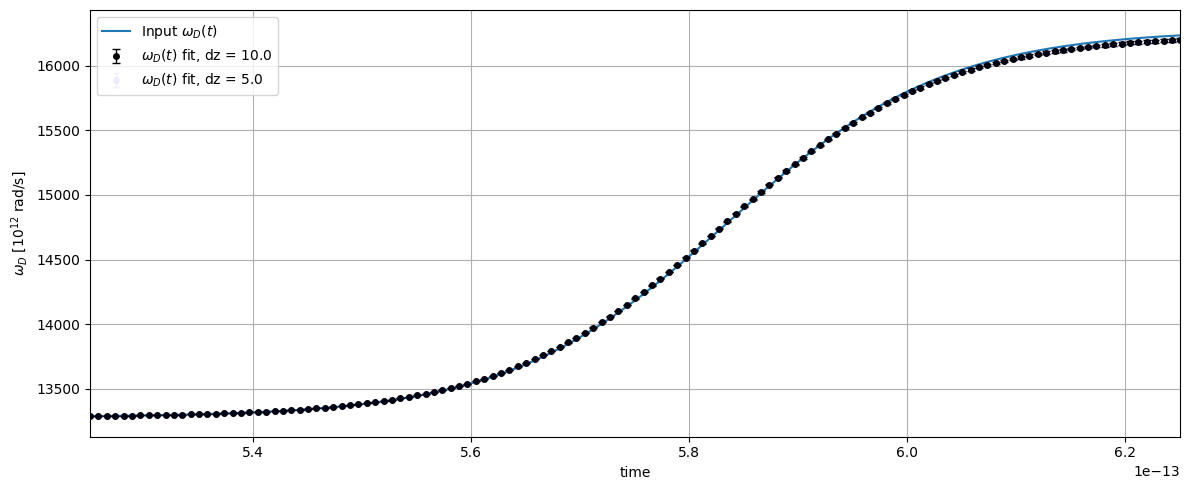

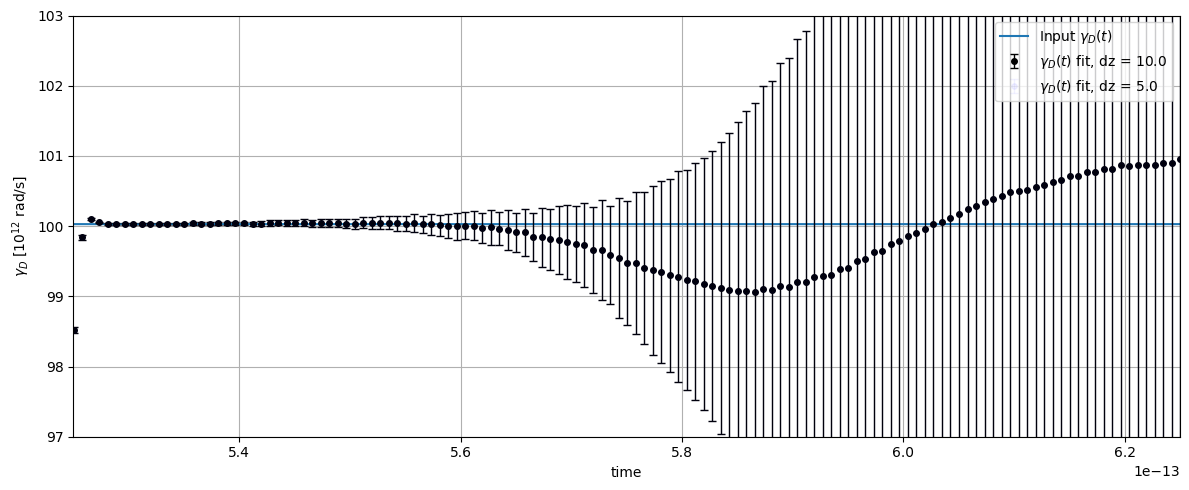

In [9]:
delta_t_correction = (result_withfilm_vary["params"].metal_i0 - result_withfilm_vary["params"].probe_r_i)*dz_retrieved / C0_SI


t_fit_full = result_inference_compare_const["time"]
omegaD_t_full = result_inference_compare_const["omegaD_t"]
gammaD_t_full = result_inference_compare_const["gammaD_t"]
del_omegaD_del_t = result_inference_compare_const["del_omegaD_del_t"]
del_gammaD_del_t = result_inference_compare_const["del_gammaD_del_t"]
# del_omegaD_del_t_err = result_inference_compare_const["del_omegaD_del_t_err"]
omegaD_err_full = result_inference_compare_const["omegaD_err"]
gammaD_err_full = result_inference_compare_const["gammaD_err"]

t_fit_full_5 = result_inference_compare_const_5["time"]
omegaD_t_full_5 = result_inference_compare_const_5["omegaD_t"]
gammaD_t_full_5 = result_inference_compare_const_5["gammaD_t"]
omegaD_err_full_5 = result_inference_compare_const_5["omegaD_err"]
gammaD_err_full_5 = result_inference_compare_const_5["gammaD_err"]

# time_correction = -2.0*(probe_r_i - metal_i0) * dz * UNIT_L / C0_SI

# Optional scaling for nicer axes
omega_scale = 1e-12   # plot omega_D in units of 1e12 rad/s
gamma_scale = 1e-12   # plot gamma_D in units of 1e12 rad/s

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T + delta_t_correction, omega_D_timedep, label="Input $\omega_D(t)$")
# plt.scatter(t_fit_full,omegaD_t_full*omega_scale,s=5,alpha=0.7)
plt.errorbar(
    t_fit_full,
    omegaD_t_full * omega_scale,
    yerr=omegaD_err_full * omega_scale,
    fmt='o',
    color='black',
    alpha=1,
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\omega_D(t)$ fit, dz = 10.0'
)
plt.errorbar(
    t_fit_full_5,
    omegaD_t_full_5 * omega_scale,
    yerr=omegaD_err_full_5 * omega_scale,
    fmt='o',
    color='blue',
    alpha=0.05,
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\omega_D(t)$ fit, dz = 5.0'
)

plt.xlabel("time")
plt.ylabel(r'$\omega_D$ [$10^{12}$ rad/s]')
plt.xlim((5.25e-13,6.25e-13))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T + delta_t_correction, gamma_D_const, label="Input $\gamma_D(t)$")
plt.errorbar(
    t_fit_full,
    gammaD_t_full * gamma_scale,
    yerr=gammaD_err_full * gamma_scale,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\gamma_D(t)$ fit, dz = 10.0'
)
plt.errorbar(
    t_fit_full_5,
    gammaD_t_full_5 * gamma_scale,
    yerr=gammaD_err_full_5 * gamma_scale,
    fmt='o',
    color='blue',
    alpha=0.05,
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\gamma_D(t)$ fit, dz = 5.0'
)
plt.xlabel("time")
plt.ylabel(r'$\gamma_D$ [$10^{12}$ rad/s]')
plt.ylim((97.,103.))
plt.xlim((5.25e-13,6.25e-13))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

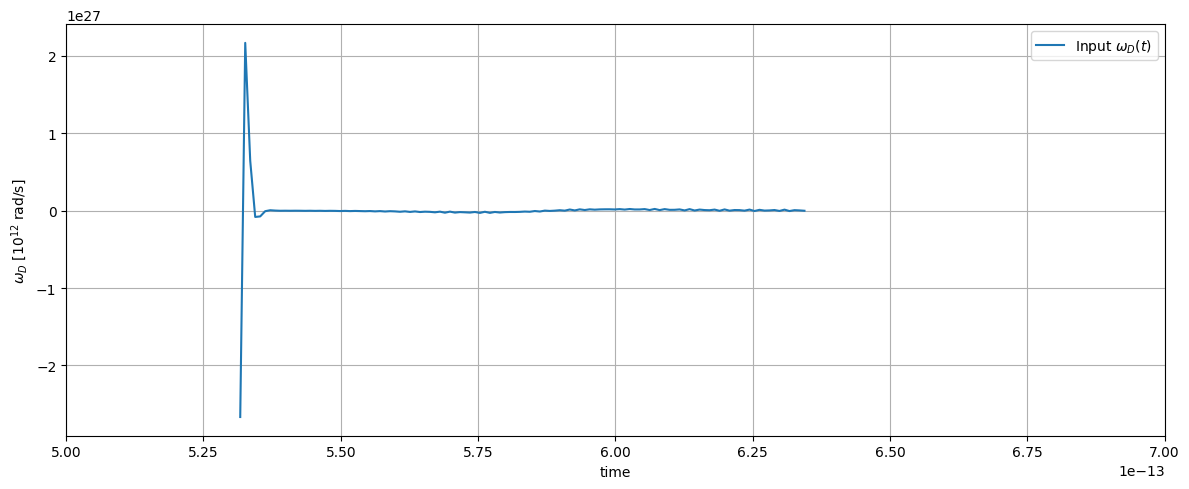

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(t_fit_full, del_gammaD_del_t, label="Input $\omega_D(t)$")
# plt.scatter(t_fit_full,omegaD_t_full*omega_scale,s=5,alpha=0.7)
# plt.errorbar(
#     t_fit_full,d, label="Input 
#     del_gammaD_del_t * omega_scale,
#     yerr=del_gammaD_del_t * omega_scale,
#     fmt='o',
#     color='black',
#     alpha=1,
#     capsize=3,
#     elinewidth=1,
#     markersize=4,
#     label=r'$\omega_D(t)$ fit, full coverage'
# )

plt.xlabel("time")
plt.ylabel(r'$\omega_D$ [$10^{12}$ rad/s]')
plt.xlim((5e-13,7e-13))
# plt.xlim((3.5e-13,5.5e-13))
# plt.ylim((13000,17500))
# plt.ylim((0.,6e4))
plt.grid(True)
plt.legend()
plt.tight_layout()

What is the resonance around f=950 THz?

In [53]:
from lightmatter.infer_drude_reflection import epsilon_drude

def plot_transmission_for_three_drude_parameter_sets(
    omega_arr=None,
    f_arr=None,
    drude_params_list=None,
    eps_inf=1.0,
    d_m=5e-9,
    freq_axis="omega",   # "omega" or "f"
    unwrap_phase=True,
    figsize=(10, 8),
    show=True,
):
    """
    Plot model reflection |t(omega)| and phase for three different choices
    of Drude parameters.

    Parameters
    ----------
    omega_arr : array-like or None
        Angular frequency array [rad/s]. Provide this OR f_arr.
    f_arr : array-like or None
        Frequency array [Hz]. If provided, converted internally to omega.
    drude_params_list : list of tuples
        Exactly three tuples:
            [(omega_D1, gamma_D1), (omega_D2, gamma_D2), (omega_D3, gamma_D3)]
        with omega_D and gamma_D in rad/s.
    eps_inf : float
        High-frequency permittivity.
    d_m : float
        Film thickness [m].
    N_reflections : int
        Number of internal reflections in the transmission model.
    freq_axis : str
        "omega" to plot against angular frequency, "f" to plot against frequency.
    unwrap_phase : bool
        Whether to unwrap the phase before plotting.
    figsize : tuple
        Figure size.
    show : bool
        Whether to call plt.show().

    Returns
    -------
    out : dict
        Contains figure, axes, omega_arr, and model transmissions.
    """
    if (omega_arr is None) == (f_arr is None):
        raise ValueError("Provide exactly one of omega_arr or f_arr.")

    if drude_params_list is None or len(drude_params_list) != 3:
        raise ValueError(
            "drude_params_list must contain exactly three tuples: "
            "[(omega_D1, gamma_D1), (omega_D2, gamma_D2), (omega_D3, gamma_D3)]"
        )

    if f_arr is not None:
        omega_arr = 2.0 * np.pi * np.asarray(f_arr, dtype=float)
    else:
        omega_arr = np.asarray(omega_arr, dtype=float)

    if freq_axis == "omega":
        xplot = omega_arr * 1e-12
        xlabel = r"$\omega$ [$10^{12}$ rad/s]"
    elif freq_axis == "f":
        xplot = omega_arr / (2.0 * np.pi) * 1e-12
        xlabel = r"$f$ [THz]"
    else:
        raise ValueError("freq_axis must be 'omega' or 'f'")

    fig, ax = plt.subplots(2, 1, figsize=figsize, sharex=True)
    r_models = []

    for i, (omega_D, gamma_D) in enumerate(drude_params_list, start=1):

        eps_drude = epsilon_drude(
            omega=omega_arr,
            eps_inf=eps_inf,
            omega_D=omega_D,
            gamma_D=gamma_D
        )

        n_sqr = eps_drude #- 1.0j/omega_arr * del_eps_del_t # this just assumes a static medium

        t_complex_vary = 1.0 + 1.0j * omega_arr * d_m / (2.0 * C0_SI) * (1.0 + n_sqr)
        r_complex_vary = (0.5j*omega_arr*d_m / C0_SI)*(n_sqr - 1.0) * t_complex_vary
        
        r_models.append(r_complex_vary)

        phase = np.angle(r_complex_vary)
        if unwrap_phase:
            phase = np.unwrap(phase)

        label = (
            rf"set {i}: $\omega_D$={omega_D:.3e} rad/s, "
            rf"$\gamma_D$={gamma_D:.3e} rad/s"
        )

        ax[0].plot(xplot, np.abs(r_complex_vary), label=label)
        ax[1].plot(xplot, phase, label=label)

    ax[0].set_ylabel(r"$|r|$")
    ax[1].set_ylabel("phase [rad]")
    ax[1].set_xlabel(xlabel)

    ax[0].grid(True)
    ax[1].grid(True)
    ax[0].legend()
    ax[1].legend()

    fig.suptitle("Frequency-dependent reflection for three Drude parameter sets", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if show:
        plt.show()

    return {
        "fig": fig,
        "axes": ax,
        "omega_arr": omega_arr,
        "t_models": r_models,
    }

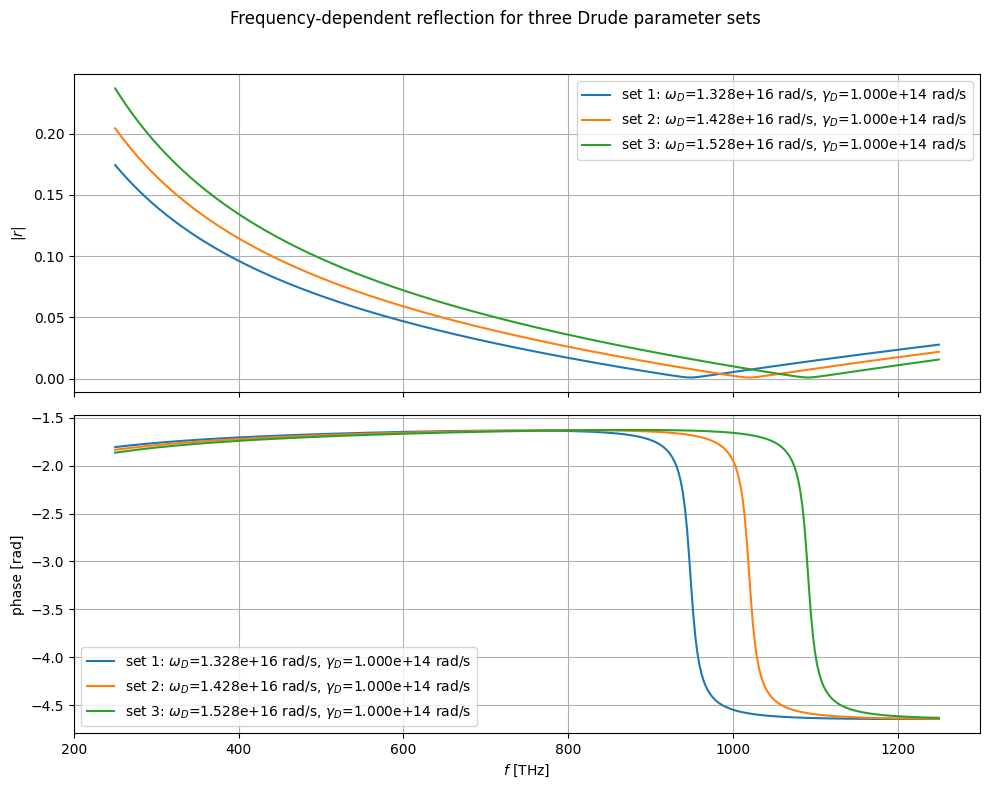

In [56]:
f_plot = np.linspace(250e12, 1250e12, 400)

x = plot_transmission_for_three_drude_parameter_sets(
    f_arr=f_plot,
    drude_params_list=[
        ((2*np.pi*2113.6)*1e12, 2*np.pi*15.92 * 1e12),
        ((2*np.pi*2113.6 + 1000.0)*1e12, 2*np.pi*15.92 * 1e12),
        ((2*np.pi*2113.6 + 2000.0)*1e12, 2*np.pi*15.92 * 1e12),
    ],
    eps_inf=5.967,
    d_m=10e-10,
    freq_axis="f",
)

In [40]:
2*np.pi*15.92

100.02831009029902

In [16]:
gammaD_t_full.shape

(58817,)

peaks in incident 59
peaks in output 58
peaks in incident 69
peaks in output 68
peaks in incident 79
peaks in output 78
peaks in incident 97
peaks in output 98
peaks in incident 117
peaks in output 117
peaks in incident 127
peaks in output 127


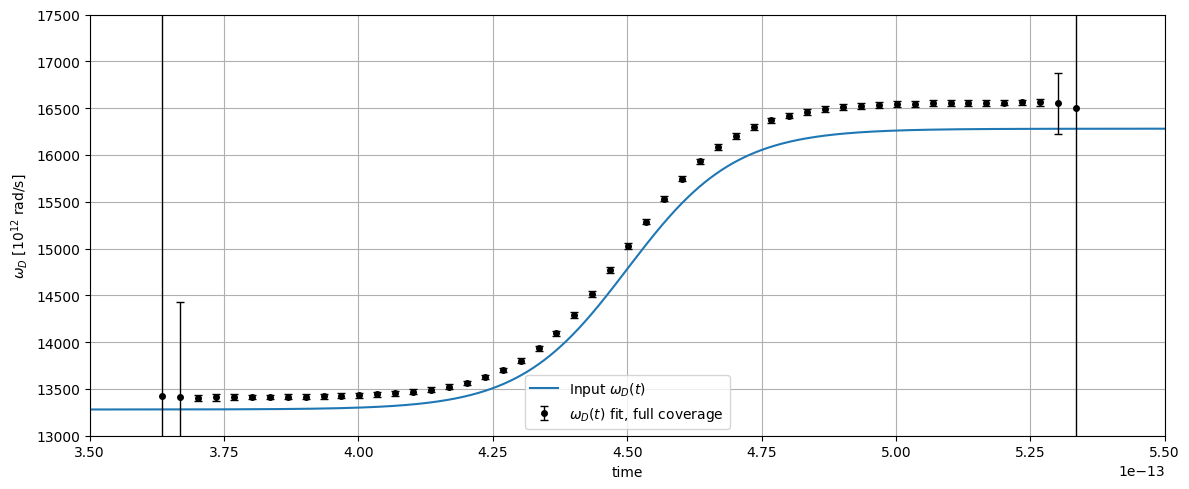

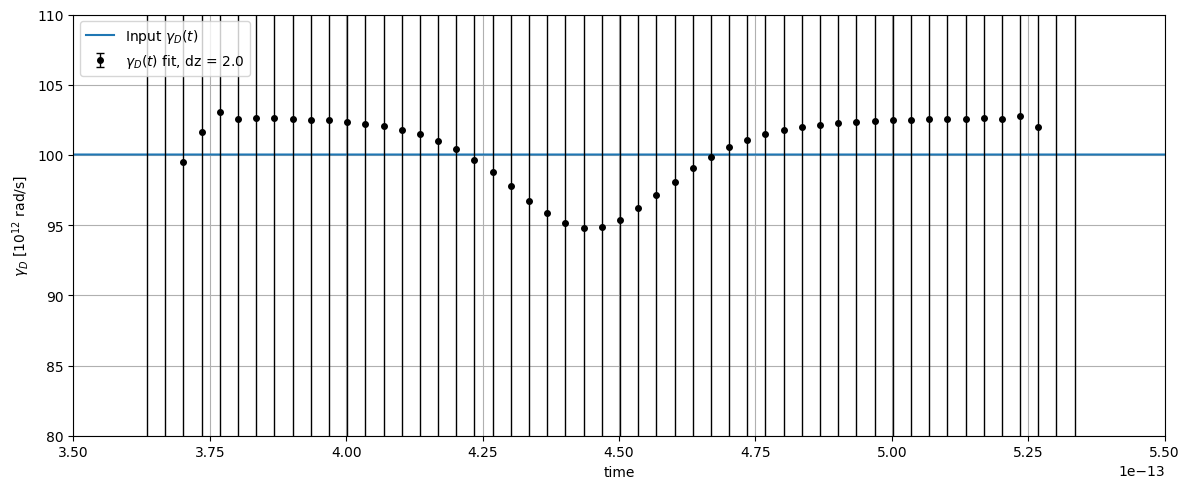

In [ ]:
from lightmatter.infer_drude_reflection import infer_drude_time_series_from_multifrequency_runs

dirname_infer = ["2026-04-22_corrected_pml_reflection_fit","step_dz_10"]
result_inference_reflections = infer_drude_time_series_from_multifrequency_runs(
    f0_arr=[300.0,350.0,400.0,500.0,600.0,650.0],
    dirname=dirname_infer,
    eps_inf=5.9673,
    N_reflections=0,
    env_frac=0.2,
    x0=(1.32e16, 1.0e14),
    bounds=((5e15, 5e13), (5e16, 1.5e14)),
    lam_smooth=0.0,   # tune this
)


t_fit_full = result_inference_reflections["time"]
omegaD_t_full = result_inference_reflections["omegaD_t"]
gammaD_t_full = result_inference_reflections["gammaD_t"]
omegaD_err_full = result_inference_reflections["omegaD_err"]
gammaD_err_full = result_inference_reflections["gammaD_err"]


# time_correction = -2.0*(probe_r_i - metal_i0) * dz * UNIT_L / C0_SI

# Optional scaling for nicer axes
omega_scale = 1e-12   # plot omega_D in units of 1e12 rad/s
gamma_scale = 1e-12   # plot gamma_D in units of 1e12 rad/s

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T, omega_D_timedep, label="Input $\omega_D(t)$")
plt.errorbar(
    t_fit_full,
    omegaD_t_full * omega_scale,
    yerr=omegaD_err_full * omega_scale,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\omega_D(t)$ fit, full coverage'
)

plt.xlabel("time")
plt.ylabel(r'$\omega_D$ [$10^{12}$ rad/s]')
# plt.xlim((4.9e-13,6.4e-13))
plt.xlim((3.5e-13,5.5e-13))
plt.ylim((13000,17500))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T, gamma_D_const, label="Input $\gamma_D(t)$")
plt.errorbar(
    t_fit_full,
    gammaD_t_full * gamma_scale,
    yerr=gammaD_err_full * gamma_scale,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\gamma_D(t)$ fit, dz = 2.0'
)

plt.xlabel("time")
plt.ylabel(r'$\gamma_D$ [$10^{12}$ rad/s]')
plt.ylim((80.,110.))
plt.xlim((3.5e-13,5.5e-13))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()